In [1]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market import Market

In [2]:
from joblib import dump, load

market = load(project_root / "results/market_simulation.joblib")

In [57]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [58]:
scenario, r_m, last_r, last_vol = make_scenario(100, "weekly", market, 500, return_last=True)

In [33]:
N = 20 # n_assets
T = 10 # n_timeperiods - the amount the model sees ahead
K = 50 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_steps = 5
n_simulations = 4

In [22]:
scenarios = generate_scenarios(K, T, N, 'weekly', market, 500)

## MPC

In [25]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

In [36]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.2, trade=0.005, risk_type='semi_variance')

In [37]:
controller.is_QP_and_DPP()

(True, True)

In [28]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner'):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [103]:
from tqdm.notebook import tqdm

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):
        # NOTE: lasts are always daily for market, and market return is too
        actual_traj, market_return, last_r_m, last_vol =\
            make_scenario(n_steps, freq, market, 500, return_last=True)

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}'):
            if step == 0:
                scenarios = generate_scenarios(K ,T, N, freq, market, burn=500)
            else:
                scenarios = generate_scenarios(K ,T, N, freq, market, burn=0, 
                                                init_value=last_r_m.iloc[step-1], 
                                                init_vol=last_vol.iloc[step-1])
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve()
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.iloc[step]])

            MPC_sim.append(x_next)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return])).cumprod() * 100

Simulations:   0%|          | 0/4 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/5 [00:00<?, ?it/s]

simulation 2:   0%|          | 0/5 [00:00<?, ?it/s]

simulation 3:   0%|          | 0/5 [00:00<?, ?it/s]

simulation 4:   0%|          | 0/5 [00:00<?, ?it/s]

In [104]:
market_sims = pd.DataFrame(market_sims)

In [105]:
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))

<Axes: >

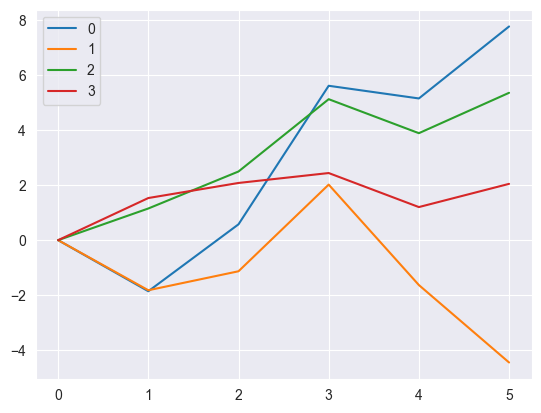

In [114]:
(market_sims.T - MPC_sims.T).plot()